# NeuraLeaf: Disentangled Neural Parametric Modeling of Leaf Shape and Deformation

Reproduction of **"NeuraLeaf: Disentangled Neural Parametric Modeling of Leaf Shape, Deformation, and Appearance"**
(Y. Yang, R. Shinoda, H. Santo, Y. Matsushita, F. Okura; *International Journal of Computer Vision* 134(10), 2026,
[DOI 10.1007/s11263-026-03024-6](https://doi.org/10.1007/s11263-026-03024-6)).

**Implementation used (operator-directed):** the authors' repository
[`Yrainy0615/NeuraLeaf`](https://github.com/Yrainy0615/NeuraLeaf) @ commit `782cafe` — the implementation of the
ICCV 2025 conference version ([arXiv:2507.12714](https://arxiv.org/abs/2507.12714)). The journal-extension repo
[`Yrainy0615/NeuraLeaf-APP`](https://github.com/Yrainy0615/NeuraLeaf-APP) (@`1d5b366`) has **byte-identical core
model files** (verified by SHA-256 for `scripts/models/decoder.py`, `generation.py`,
`scripts/utils/geom_utils.py`, `scripts/utils/utils.py`), so the shape/deformation core demonstrated here is the
same implementation as the journal paper's core.

**Pretrained weights:** authors' Google Drive linked in the repo README (`baseshape_l.pth`, `deform.pth`,
`encoder.pth`; downloaded at runtime, never redistributed here).

## What this notebook demonstrates (partial demonstration, single-example scale)
1. **Base-shape generation** from the learned shape latent space: shape code → 2D SDF → mask → triangulated flat mesh (paper Sec. 3.1).
2. **Skeleton-free skinning deformation**: skinning-weight decoder + transformation decoder + linear blend skinning with K = 1000 control points (paper Sec. 3.3, Eq. 7–9).
3. **Deformation transfer** (same deformation latent, different leaf species; paper Fig. 7 / Fig. S3) and shape/deformation **interpolation** (paper Fig. S2 / generation API).
4. **Fitting round-trip** (paper Sec. 5): latent-code inversion with the authors' 3D-convolution encoders followed by direct optimization of the latent codes against one model-generated deformed leaf (deterministic indices; no external scan).

## Explicitly out of scope
- Texture / appearance spaces (CycleGAN texture generator; journal PBR ControlNet) — **no public pretrained texture checkpoint exists** (the journal repo's weights link is an unfilled placeholder).
- Training from scratch, dataset-scale benchmarks, DeformLeaf dataset download.
- The fitting demo is a **round-trip on a model-generated leaf**, not a fit to a real scan; it does not verify the paper's published dataset-level accuracies.

## 実行内容(日本語概要)
- **対象論文**: NeuraLeaf(IJCV 2026, ジャーナル版)。**使用コード**: 著者らの会議版(ICCV 2025)実装リポジトリ(オペレーター指定)。ジャーナル版リポジトリのコアモデルファイルとバイト単位で同一であることを SHA-256 で確認済みです。
- **デモ内容**: ① 学習済み shape latent からの葉の平面形状生成(SDF→マスク→メッシュ)、② スケルトン不要スキニング(K=1000 制御点, LBS)による 3D 変形、③ 種間変形転送・潜在空間補間、④ エンコーダによる潜在コード反転 + 直接最適化のフィッティング往復実験(モデル生成葉 1 枚)。
- **スコープ外**: テクスチャ/外観空間(公開重みなし)、学習、データセット規模の評価、DeformLeaf データセットのダウンロード。

## How to run / 実行方法

1. **Runtime → Change runtime type → T4 GPU** (standard memory). The fitting part uses the authors' CUDA
   registration path (`probreg` + CuPy) and GPU-accelerated torch operations.
   **ランタイム → ランタイムのタイプを変更 → T4 GPU を選択してください。**
2. **Runtime → Run all**. The notebook is designed to run top-to-bottom on a fresh runtime.
   **「ランタイム → すべてのセルを実行」で先頭から順に実行されます。**
3. Expected wall time: dominated by dependency installation (the PyTorch3D build can take on the order of
   10–30 minutes); model download is small (a few checkpoint files). Measured timings of the validated run
   are printed in the cells and summarized in the accompanying report.
   所要時間の大部分は依存関係(pytorch3d のビルド)で、目安は合計 20–45 分程度です(実測値はレポート参照)。
4. Limitations: the checkpoints are fetched from the authors' Google Drive folder at runtime — if Drive
   throttles or the link changes, that step fails explicitly. Free-tier availability and speed may differ.
   チェックポイントは著者の Google Drive から実行時にダウンロードします(リンク切断時は明示的にエラー表示)。

### Environment check
Prints the Python/PyTorch/CUDA versions and the allocated GPU. The notebook **requires a GPU runtime**
(the authors' fitting path hard-codes CUDA registration) and fails loudly with instructions otherwise.
**環境確認セル**: Python / PyTorch / CUDA / GPU 名を表示し、GPU ランタイムでない場合は明示的に停止します。

In [ ]:
import sys, torch, subprocess

print("Python:", sys.version.split()[0])
print("torch :", torch.__version__, "| CUDA build:", torch.version.cuda)
if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. Select 'Runtime > Change runtime type > T4 GPU' and rerun.\n"
        "GPU ランタイムを選択してから再実行してください。"
    )
print("GPU   :", torch.cuda.get_device_name(0),
      f"| VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
torch.manual_seed(0)
import numpy as np
np.random.seed(0)
print("Seeds fixed: torch=0, numpy=0")

Python: 3.13.15
torch : 2.11.0+cu128 | CUDA build: 12.8
GPU   : Tesla T4 | VRAM: 15.6 GB
Seeds fixed: torch=0, numpy=0


### Install dependencies (part 1: Python packages)
Installs the packages the author code needs for this demo: `meshlib` (point-cloud triangulation,
as in `mask2mesh`), `taichi` (import chain of `scripts/utils/utils.py` → `scripts/data/mask_sdf.py`),
`probreg` (Coherent Point Drift registration used by the authors' fitting pipeline), `gdown`
(Google Drive download). CuPy is installed matching the runtime CUDA major version if absent
(the authors' `rigid_cpd_cuda` imports CuPy unconditionally). We deliberately do **not** install the
repo's full `requirements.txt` (it pulls unrelated heavy packages such as Gradio/Open3D).
**依存関係インストール(1/2)**: デモに必要なパッケージのみをインストールします(CuPy は CUDA のメジャーバージョンに合わせて選択)。

In [ ]:
import subprocess, torch, time

def pip(pkg, attempts=3):
    for i in range(attempts):
        r = subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                            "--timeout", "60", "--retries", "5"] + pkg.split(),
                           capture_output=True, text=True, timeout=1800)
        if r.returncode == 0:
            print("installed:", pkg, flush=True)
            return
        print(f"pip attempt {i+1} failed for {pkg}:", (r.stderr or "")[-800:], flush=True)
    raise RuntimeError(f"pip install failed after retries: {pkg}")

# idempotent installs; trimesh and pymeshlab are required by the authors' scripts/utils/utils.py
for p in ["meshlib", "taichi", "gdown", "cython", "ninja", "probreg", "trimesh", "pymeshlab"]:
    t0 = time.time(); pip(p); print(f"  ({time.time()-t0:.0f} s)", flush=True)

try:
    import cupy  # noqa: F401
    print("cupy already present:", cupy.__version__)
except ImportError:
    cu_major = (torch.version.cuda or "none").split(".")[0]
    if cu_major in ("12", "13"):
        pip(f"cupy-cuda{cu_major}x")
    elif cu_major == "11":
        pip("cupy-cuda11x")
    else:
        raise RuntimeError(f"No CuPy wheel for CUDA={torch.version.cuda}; GPU runtime required.")
print("dependency part 1 done")

installed: meshlib


  (8 s)


installed: taichi


  (6 s)


installed: gdown


...

installed: trimesh


  (3 s)


installed: pymeshlab


  (8 s)


cupy already present: 14.0.1
dependency part 1 done


### Install dependencies (part 2: PyTorch3D)
The author code uses PyTorch3D for quaternion→rotation-matrix transforms, the `Meshes` container, and
chamfer/mesh losses. PyTorch3D publishes prebuilt wheels only for specific (python, CUDA, torch)
combinations, so this cell (1) tries the matching prebuilt wheel index and (2) otherwise builds the
CPU extension from the authors' recommended `stable` branch. With the CPU extension, quaternion
transforms and `Meshes` still run on GPU tensors; only `chamfer_distance`/kNN are executed on CPU
tensors later (same chamfer algorithm — this is a device-placement adaptation, documented where used).
This build is the slowest setup step (on the order of 10–25 min; measured below).
**依存関係インストール(2/2)**: PyTorch3D をインストールします。事前ビルド wheel が無い場合は stable ブランチからビルドします(最も時間のかかる工程)。

In [ ]:
import time, os, subprocess, importlib.util, sys, torch

t0 = time.time()
if importlib.util.find_spec("pytorch3d") is not None:
    print("pytorch3d already present")
else:
    # (1) try the official prebuilt wheel index for this exact python/cuda/torch combo
    pyv = f"{sys.version_info.major}{sys.version_info.minor}"
    cu = (torch.version.cuda or "cpu").split(".")[0]
    tv = "".join(torch.__version__.split("+")[0].split(".")[:2])
    wheel_index = f"https://dl.fbaipublicfiles.com/pytorch3d/packaging/wheels/py{pyv}_cu{cu}_pyt{tv}/download.html"
    print("trying prebuilt wheel index:", wheel_index)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-index",
                    "pytorch3d", "-f", wheel_index], capture_output=True, text=True)
    present = importlib.util.find_spec("pytorch3d") is not None
    if not present:
        # (2) build the CPU extension from the stable branch (documented adaptation)
        print("no prebuilt wheel; building CPU extension from pytorch3d @stable "
              "(this takes on the order of 10-30 minutes)...", flush=True)
        env = dict(os.environ, FORCE_CUDA="0", MAX_JOBS="2")
        r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-build-isolation",
                            "git+https://github.com/facebookresearch/pytorch3d.git@stable"],
                           env=env)
        if r.returncode != 0:
            raise RuntimeError("pytorch3d build failed")
    present = importlib.util.find_spec("pytorch3d") is not None
    if not present:
        raise RuntimeError("pytorch3d installation failed")

import pytorch3d  # noqa: E402
print("pytorch3d", pytorch3d.__version__, f"| install time: {time.time()-t0:.0f} s")

trying prebuilt wheel index: https://dl.fbaipublicfiles.com/pytorch3d/packaging/wheels/py313_cu12_pyt211/download.html


no prebuilt wheel; building CPU extension from pytorch3d @stable (this takes on the order of 10-30 minutes)...


pytorch3d 0.7.8 | install time: 1709 s


### Fetch the authors' implementation at a pinned revision
Clones `Yrainy0615/NeuraLeaf` and checks out the pinned commit `782cafe` (the revision inspected when
preparing this notebook). The repository contains only code and one teaser image (no bundled datasets
or weights). We install only the subset of `requirements.txt` needed here.
**著者実装リポジトリを指定コミット(782cafe)で取得します。**(データセット/重みの同梱はありません)

In [ ]:
import os, subprocess

REPO_DIR = "/content/NeuraLeaf"
PIN = "782cafe313e0e45c374f8e3503335e501a4ede57"
if not os.path.exists(REPO_DIR):
    r = subprocess.run(["git", "clone", "-q", "https://github.com/Yrainy0615/NeuraLeaf.git", REPO_DIR],
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError("git clone failed: " + r.stderr[-1000:])
r = subprocess.run(["git", "-C", REPO_DIR, "fetch", "-q", "origin", PIN], capture_output=True, text=True)
r = subprocess.run(["git", "-C", REPO_DIR, "checkout", "-q", "FETCH_HEAD"], capture_output=True, text=True)
if r.returncode != 0:
    raise RuntimeError("checkout failed: " + r.stderr[-1000:])
head = subprocess.run(["git", "-C", REPO_DIR, "rev-parse", "HEAD"],
                      capture_output=True, text=True).stdout.strip()
print("checked out:", head)
assert head == PIN, "pinned commit mismatch"
print("repo contents:", sorted(os.listdir(REPO_DIR)))

checked out: 782cafe313e0e45c374f8e3503335e501a4ede57
repo contents: ['.git', '.gitignore', 'Dockerfile', 'README.md', 'assets', 'fitting.py', 'generation.py', 'requirements.txt', 'scripts']


### Download the pretrained checkpoints (authors' Google Drive)
Fetches `baseshape_l.pth` (larger base-shape space; the fitting entry point's default), `deform.pth`, and
`encoder.pth` from the Google Drive folder linked in the repo README. Prints file sizes and SHA-256 so the
byte content of this run is auditable. If Google Drive denies or throttles the download, this cell fails
explicitly (no silent substitution).
**学習済みチェックポイントを著者の Google Drive から取得し、サイズと SHA-256 を表示します。**(Drive 側の制限時は明示的にエラー)

In [ ]:
import os, glob, hashlib, subprocess

CKPT_DIR = "/content/checkpoints"
url = "https://drive.google.com/drive/folders/1v9K7HJJVlCXkPfgXuEumLp9AP8iIS14G"
r = subprocess.run([sys.executable, "-m", "gdown", "--folder", url, "-O", CKPT_DIR, "--remaining-ok"],
                   capture_output=True, text=True)
print(r.stdout[-1500:])
if r.returncode != 0:
    print(r.stderr[-1500:])
    raise RuntimeError("checkpoint download failed (Google Drive unavailable or link changed)")

ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, "**", "*.pth"), recursive=True))
assert ckpts, "no .pth files downloaded"
for p in ckpts:
    h = hashlib.sha256(open(p, "rb").read()).hexdigest()
    print(f"{os.path.relpath(p, CKPT_DIR):40s} {os.path.getsize(p)/1e6:8.2f} MB  sha256={h[:16]}...")

Processing file 1f2y4O-fx-FApF1v-4gbHQ80jaqEsrZOr baseshape_l_latest.pth
Processing file 1zr5eECHDE4Pd4IxEnaTa3Z3XegvXgnK2 baseshape_l.pth
Processing file 1Dm_6Qkl_AMBQc6RO9z_PwYBZ3r4YuOEL baseshape.pth
Processing file 16f3Opay8_-T7X8CHZkOSCFdpqaBPD7VQ deform.pth
Processing file 1ehXUsMD3LHIEgzyMcV721Ei13J0Muru6 encoder.pth



baseshape.pth                               89.03 MB  sha256=7feb3f89bb457fd6...


baseshape_l.pth                            105.84 MB  sha256=91e0462b7c67fb19...


baseshape_l_latest.pth                     105.84 MB  sha256=5829bf754b20a50d...
deform.pth                                   5.35 MB  sha256=41cb2d733340ef89...


encoder.pth                                102.30 MB  sha256=1271e998005ae2c9...


### Load the pretrained NeuraLeaf model (paper Sec. 3.1 + 3.3)
Builds the three networks exactly as the authors' `generation.py` does and loads the checkpoints:
- **Shape decoder** `UDFNetwork` (8-layer weight-normalized MLP; 2D point x ∈ [0,1]² + shape latent z_s → signed distance; paper Eq. 1).
- **Skinning-weights decoder** `SWPredictor` (Fourier-encoded point + z_s → softmax weights over K = 1000 control points; paper Eq. 9).
- **Transformation decoder** `TransPredictor` (Fourier-encoded control point + z_d → per-control-point translation + quaternion; paper Eq. 8).

Latent dimensions are **derived from the checkpoint tensors** (and cross-checked against the YAML
configs) so no unobserved value is hard-coded. Note: the paper supplement states N_d = 256 while the
repo config says 128 — the checkpoint arbitrates; the resolved value is printed.
**学習済みモデルを読み込みます。潜在次元はチェックポイントのテンソル形状から決定し、YAML 設定と突き合わせて表示します。**

In [ ]:
import torch, yaml, numpy as np

os.chdir(REPO_DIR)                     # author code expects repo root as CWD
sys.path.insert(0, REPO_DIR)           # scripts.* namespace imports
sys.path.insert(0, os.path.join(REPO_DIR, "scripts"))  # neuralbs.py: "from utils import geom_utils"
device = "cuda"

CFG        = yaml.safe_load(open("scripts/configs/bashshape.yaml"))
CFG_DEFORM = yaml.safe_load(open("scripts/configs/deform.yaml"))

def find_ckpt(name):
    hits = [p for p in ckpts if os.path.basename(p) == name]
    assert hits, f"checkpoint {name} not found among {[os.path.basename(p) for p in ckpts]}"
    return hits[0]

def load_ckpt(path):
    try:
        return torch.load(path, map_location="cpu")          # tensors-only -> weights_only path OK
    except Exception as e:
        print("weights_only load failed, retrying with weights_only=False:", type(e).__name__)
        return torch.load(path, map_location="cpu", weights_only=False)

ck_shape  = load_ckpt(find_ckpt("baseshape_l.pth"))
ck_deform = load_ckpt(find_ckpt("deform.pth"))

# ---- infer latent dims from checkpoint tensors (no hard-coded dims) ----
tp0 = ck_deform["Transpredictor"]["layers.0.0.weight"]           # [W, 63 + latent_dim]
sp0 = ck_deform["SWpredictor"]["layers.0.0.weight"]              # [W, 63 + latent_dim]
deform_latent_dim_ckpt  = tp0.shape[1] - 63
shape_latent_dim_ckpt   = sp0.shape[1] - 63
dec_keys = list(ck_shape["decoder"].keys())
print("decoder state-dict keys (first 6):", dec_keys[:6])
# weight_norm modules store weight_v/weight_g instead of a plain weight
dec0_key = next(k for k in dec_keys if k.startswith("lin0") and k.endswith(("weight_v", "weight")))
dec0 = ck_shape["decoder"][dec0_key]                             # [hidden, 2 + N_s]
shape_hidden_ckpt    = dec0.shape[0]
print(f"checkpoint-derived: N_s={shape_latent_dim_ckpt}, N_d={deform_latent_dim_ckpt}, hidden={shape_hidden_ckpt}")
print(f"yaml values       : N_s={CFG['Base']['Z_DIM']}, N_d={CFG_DEFORM['NBS']['lat_dim']}, "
      f"hidden={CFG['Base']['decoder_hidden_dim']}, num_bones={CFG_DEFORM['NBS']['num_bones']}")

from scripts.models.decoder import UDFNetwork, SWPredictor, TransPredictor

shape_decoder = UDFNetwork(d_in=shape_latent_dim_ckpt, d_out=1, d_hidden=shape_hidden_ckpt,
                           n_layers=CFG["Base"]["decoder_nlayers"], udf_type="sdf", geometric_init=False)
shape_decoder.load_state_dict(ck_shape["decoder"])
k = ck_shape.get("k", torch.tensor(1.0))
shape_codes = ck_shape["latent_shape"]["weight"]

num_bones = ck_deform["bone"].shape[0]                            # K from the checkpoint itself
sw_predictor    = SWPredictor(num_bones=num_bones, latent_dim=shape_latent_dim_ckpt)
trans_predictor = TransPredictor(num_bones=num_bones, latent_dim=deform_latent_dim_ckpt)
sw_predictor.load_state_dict(ck_deform["SWpredictor"])
trans_predictor.load_state_dict(ck_deform["Transpredictor"])
deform_codes = ck_deform["deform_codes"]["weight"]
bone = ck_deform["bone"].to(device)
# keep the learned code tables on the device (the authors' Generator does this internally)
shape_codes = shape_codes.to(device)
deform_codes = deform_codes.to(device)

shape_decoder, sw_predictor, trans_predictor = [m.eval().to(device)
                                                for m in (shape_decoder, sw_predictor, trans_predictor)]
k = k.to(device) if isinstance(k, torch.Tensor) else k

print(f"shape codes : {tuple(shape_codes.shape)}   deform codes: {tuple(deform_codes.shape)}")
print(f"k (mask temperature) = {float(k):.4f}")
print(f"control points K = {num_bones} | bone bbox min={bone.detach().min(0).values.cpu().numpy().round(3)} "
      f"max={bone.detach().max(0).values.cpu().numpy().round(3)}")

decoder state-dict keys (first 6): ['lin0.bias', 'lin0.weight_g', 'lin0.weight_v', 'lin1.bias', 'lin1.weight_g', 'lin1.weight_v']
checkpoint-derived: N_s=256, N_d=128, hidden=1024
yaml values       : N_s=256, N_d=128, hidden=1024, num_bones=1000


/usr/local/lib/python3.13/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


shape codes : (5706, 256)   deform codes: (152, 128)
k (mask temperature) = 517.0479
control points K = 1000 | bone bbox min=[-25.1   -23.918 -22.576] max=[21.684 25.495 20.486]


### Static mesh renderer (matplotlib)
The authors' repo does not ship a Colab-compatible offscreen renderer, so this notebook renders meshes
with a small matplotlib helper (Lambert-shaded triangles from packed vertex/face arrays). These static
renders are the persistent visual evidence of this run.
**静止画レンダラ**: 著者リポジトリには Colab 向け描画機能がないため、matplotlib による陰影付き描画ヘルパーを用意しました(本実行の永続的な視覚的証拠になります)。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def render_mesh(ax, verts, faces, color="#5da257", elev=90, azim=-90, title=None, point_size=1):
    """Lambert-shaded 3D render of a (verts, faces) mesh; falls back to a scatter for empty faces."""
    verts = np.asarray(verts, dtype=np.float32); faces = np.asarray(faces)
    if faces.size == 0:
        ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], s=point_size, c=color, depthshade=False)
    else:
        tri = verts[faces]
        n = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
        n /= (np.linalg.norm(n, axis=1, keepdims=True) + 1e-9)
        light = np.array([0.3, 0.4, 1.0]); light = light / np.linalg.norm(light)
        inten = 0.30 + 0.70 * np.clip(np.abs(n) @ np.abs(light), 0, 1)
        rgb = plt.matplotlib.colors.to_rgb(color)
        facecolors = np.clip(np.array(rgb)[None, :] * inten[:, None], 0, 1)
        pc = Poly3DCollection(tri, facecolors=facecolors, edgecolors="none")
        ax.add_collection3d(pc)
    lim = np.abs(verts).max()
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    if title: ax.set_title(title, fontsize=9)

def mesh_arrays(mesh):
    """pytorch3d Meshes -> (verts, faces) numpy arrays on CPU."""
    return (mesh.verts_packed().detach().cpu().numpy(),
            mesh.faces_packed().detach().cpu().numpy())
print("renderer ready")

renderer ready


### Step 1 — Base-shape generation from the learned shape space (paper Sec. 3.1)
Evaluates the shape decoder on a 256×256 grid (via the authors' `latent_to_mask`: SDF → hardsigmoid with
learned temperature k), then converts the mask to a flat triangulated mesh with the authors' `mask2mesh`
(meshlib point-cloud triangulation, ≤15000 vertices). Four shape indices are selected deterministically
from the checkpoint's learned shape-code table.
**Shape latent → 2D SDF → マスク → 平面メッシュ生成(論文 Sec. 3.1)。形状インデックスは決定論的に選択します。**

[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.13.15


[Taichi] Starting on arch=cuda
selected shape indices: [3637, 4415, 5125, 5681] | deform index for later steps: 143


generated 4 base meshes in 1.8 s


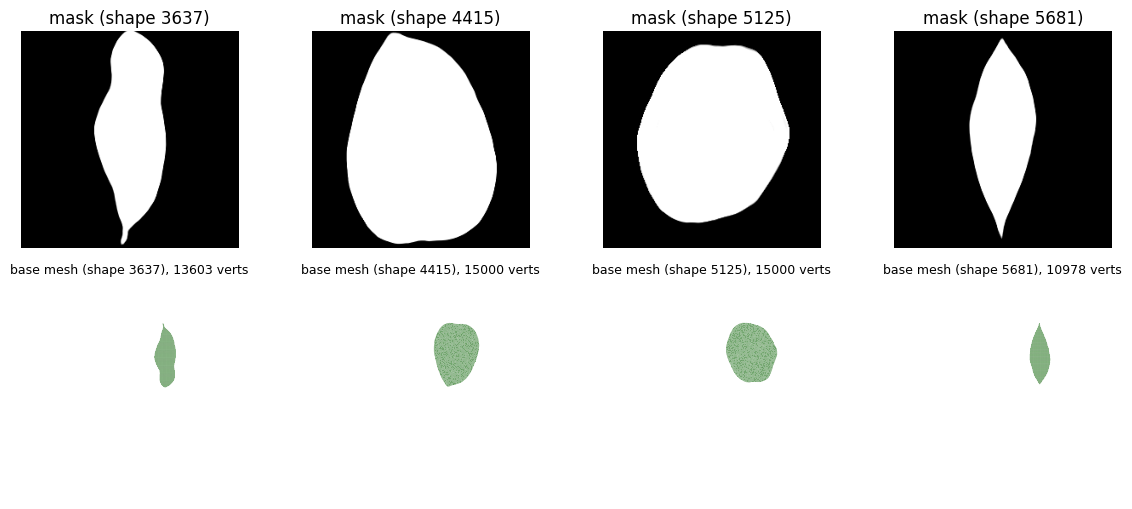

shape 3637: verts= 13603 faces= 26966 xy extent=(0.34..0.66, 0.00..0.98)
shape 4415: verts= 15000 faces= 29849 xy extent=(0.16..0.84, 0.02..0.98)
shape 5125: verts= 15000 faces= 29843 xy extent=(0.16..0.85, 0.07..0.88)
shape 5681: verts= 10978 faces= 21796 xy extent=(0.35..0.65, 0.05..0.94)


In [ ]:
import time, torch, numpy as np, matplotlib.pyplot as plt
from scripts.utils.utils import latent_to_mask
from scripts.utils.geom_utils import mask2mesh

rng = np.random.RandomState(0)
shape_ids = sorted(rng.choice(len(shape_codes), size=min(4, len(shape_codes)), replace=False).tolist())
deform_id_demo = int(rng.choice(len(deform_codes)))
print("selected shape indices:", shape_ids, "| deform index for later steps:", deform_id_demo)

t0 = time.time()
masks, base_meshes = [], []
for sid in shape_ids:
    z_s = shape_codes[sid].unsqueeze(0)                        # (1, N_s)
    mask = latent_to_mask(z_s, shape_decoder, k=k, size=256)   # (1, 256, 256), 1 = inside leaf
    masks.append(mask[0].detach().cpu().numpy())
    base_meshes.append(mask2mesh([mask]))                      # author's SDF->mask->mesh path
print(f"generated {len(shape_ids)} base meshes in {time.time()-t0:.1f} s")

fig = plt.figure(figsize=(12, 5.2))
for i, sid in enumerate(shape_ids):
    ax = fig.add_subplot(2, len(shape_ids), i + 1); ax.imshow(masks[i], cmap="gray"); ax.set_axis_off()
    ax.set_title(f"mask (shape {sid})")
    ax = fig.add_subplot(2, len(shape_ids), len(shape_ids) + i + 1, projection="3d")
    v, f = mesh_arrays(base_meshes[i])
    render_mesh(ax, v, f, elev=90, azim=-90, title=f"base mesh (shape {sid}), {len(v)} verts")
plt.tight_layout(); plt.show()
for i, sid in enumerate(shape_ids):
    v, f = mesh_arrays(base_meshes[i])
    print(f"shape {sid}: verts={len(v):6d} faces={len(f):6d} "
          f"xy extent=({v[:,0].min():.2f}..{v[:,0].max():.2f}, {v[:,1].min():.2f}..{v[:,1].max():.2f})")

### Step 2 — Skeleton-free skinning deformation (paper Sec. 3.3, Eq. 7–9)
For one base shape, predicts per-vertex skinning weights (softmax over K = 1000 control points) and
per-control-point rigid transforms (translation + quaternion) from the deformation latent, then applies
the authors' linear blend skinning (`Generator.deform_lbs`, paper Eq. 7). Also visualizes the dominant
control point per vertex — the skinning-weight field that ties deformation to the base shape.
**スキニング重み(制御点 K=1000 の softmax)と制御点ごとの剛体変換を予測し、LBS で変形します。主要制御点の空間分布も可視化します。**

deformation magnitude (canonical units): mean=0.1334 max=0.3717 z-range=[-0.056, 0.040]
skinning weights: K=1000 control points, per-vertex sum=1.0000 (softmax -> 1)


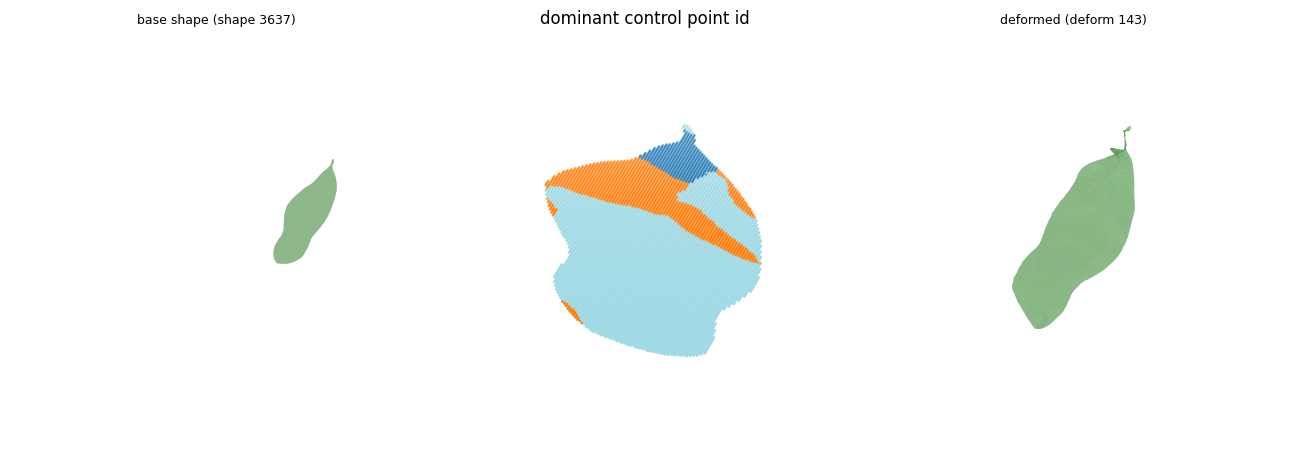

In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt
from generation import Generator

generator = Generator(device=device, shape_decoder=shape_decoder, sw_predictor=sw_predictor,
                      trans_predictor=trans_predictor, bone=bone,
                      shape_codes=shape_codes, deform_codes=deform_codes, k=k)

sid, did = shape_ids[0], deform_id_demo          # deterministic indices from Step 1
z_s = shape_codes[sid].unsqueeze(0); z_d = deform_codes[did].unsqueeze(0)

with torch.no_grad():
    base_mask = latent_to_mask(z_s, shape_decoder, k=k, size=256)
    base_mesh = mask2mesh([base_mask]).to(device)
    base_pts  = base_mesh.verts_packed().unsqueeze(0)
    base_pts  = base_pts - base_pts.mean(1, keepdim=True)       # author's centering
    base_fcs  = base_mesh.faces_packed().unsqueeze(0)

    sw = sw_predictor(latent_code=z_s, centers=base_pts)        # (1, N, K) softmax weights
    rts = trans_predictor(latent_code=z_d, centers=bone)        # (1, K, 7) translation+quaternion
    deformed_pts = generator.deform_lbs(base_pts, sw, rts)      # LBS, paper Eq. 7

disp = (deformed_pts - base_pts)[0].cpu()
mag = disp.norm(dim=1)
print(f"deformation magnitude (canonical units): mean={mag.mean():.4f} max={mag.max():.4f} "
      f"z-range=[{disp[:,2].min():.3f}, {disp[:,2].max():.3f}]")
print(f"skinning weights: K={sw.shape[-1]} control points, per-vertex sum={sw.sum(-1).mean():.4f} (softmax -> 1)")

dom = sw[0].argmax(-1).cpu().numpy()                            # dominant control point per vertex
v_b, f_b = mesh_arrays(base_mesh)                               # base arrays
v_d, f_d = deformed_pts[0].detach().cpu().numpy(), base_fcs[0].cpu().numpy()

fig = plt.figure(figsize=(13, 4.6))
ax = fig.add_subplot(1, 3, 1, projection="3d"); render_mesh(ax, v_b, f_b, elev=75, azim=-60, title=f"base shape (shape {sid})")
ax = fig.add_subplot(1, 3, 2, projection="3d")
pc = ax.scatter(v_b[:,0], v_b[:,1], v_b[:,2], c=dom % 20, cmap="tab20", s=1)
ax.set_title("dominant control point id"); ax.set_axis_off(); ax.view_init(elev=75, azim=-60)
ax = fig.add_subplot(1, 3, 3, projection="3d"); render_mesh(ax, v_d, f_d, elev=75, azim=-60, title=f"deformed (deform {did})")
plt.tight_layout(); plt.show()

### Step 3 — Deformation transfer across species (paper Fig. 7 / Fig. S3)
The core claim of the disentangled deformation space: **one fixed deformation latent code** deforms
**different leaf base shapes** consistently. Generates each base shape from Step 1 and applies the same
deformation code; writes a small results table (`deform_transfer.csv`) with per-mesh statistics.
**同一の deformation latent を異なる種の基本形状に適用する変形転送(論文 Fig. 7 / Fig. S3)。結果表を CSV 出力します。**

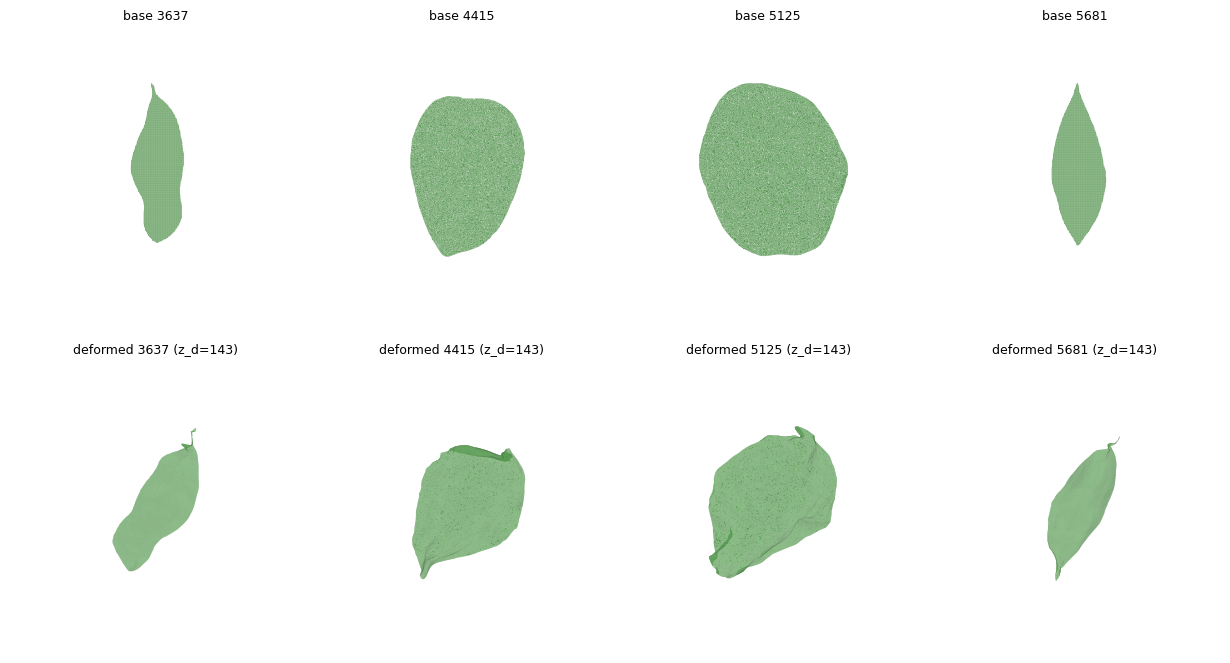

wrote /content/neuraleaf_results/deform_transfer.csv
dict_keys(['shape_idx', 'deform_idx', 'n_verts', 'deform_mean', 'deform_max', 'z_extent']) | rows: 4


In [ ]:
import csv, torch, numpy as np, matplotlib.pyplot as plt
import os

OUT_DIR = "/content/neuraleaf_results"; os.makedirs(OUT_DIR, exist_ok=True)
rows = []
deformed_transfer = []
with torch.no_grad():
    z_d = deform_codes[deform_id_demo].unsqueeze(0)             # fixed deformation latent
    rts = trans_predictor(latent_code=z_d, centers=bone)
    for sid in shape_ids:
        z_s = shape_codes[sid].unsqueeze(0)
        mask = latent_to_mask(z_s, shape_decoder, k=k, size=256)
        mesh_b = mask2mesh([mask]).to(device)
        bp = mesh_b.verts_packed().unsqueeze(0); bp = bp - bp.mean(1, keepdim=True)
        bf = mesh_b.faces_packed().unsqueeze(0)
        sw = sw_predictor(latent_code=z_s, centers=bp)
        dp = generator.deform_lbs(bp, sw, rts)
        deformed_transfer.append((sid, bp[0].cpu().numpy(), bf[0].cpu().numpy(), dp[0].cpu().numpy()))
        mag = (dp - bp).norm(dim=2)[0].cpu()
        rows.append({"shape_idx": sid, "deform_idx": deform_id_demo, "n_verts": int(bp.shape[1]),
                     "deform_mean": float(mag.mean()), "deform_max": float(mag.max()),
                     "z_extent": float(dp[...,2].max()-dp[...,2].min())})

fig = plt.figure(figsize=(3.1*len(shape_ids), 7))
for i, (sid, vb, fb, vd) in enumerate(deformed_transfer):
    ax = fig.add_subplot(2, len(shape_ids), i+1, projection="3d")
    render_mesh(ax, vb, fb, elev=90, azim=-90, title=f"base {sid}")
    ax = fig.add_subplot(2, len(shape_ids), len(shape_ids)+i+1, projection="3d")
    render_mesh(ax, vd, fb, elev=75, azim=-60, title=f"deformed {sid} (z_d={deform_id_demo})")
plt.tight_layout(); plt.show()

csv_path = os.path.join(OUT_DIR, "deform_transfer.csv")
with open(csv_path, "w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
print("wrote", csv_path); print(rows[0].keys().__str__(), "| rows:", len(rows))

### Step 4 — Latent-space interpolation (paper Fig. S2 / Fig. S3; `generation.py` API)
Left: **shape interpolation** — two shape codes are linearly interpolated with the deformation fixed
(smoothness of the base-shape latent space). Right: **deformation interpolation** — two deformation codes
are interpolated with the shape fixed (continuity of the deformation space).
**形状補間(左)と変形補間(右)**: 各潜在空間の滑らかさを 1 例ずつ可視化します。

shape interp: 3637 -> 5125 (deform 143 fixed) | deform interp: 59 -> 33 (shape 4415 fixed)


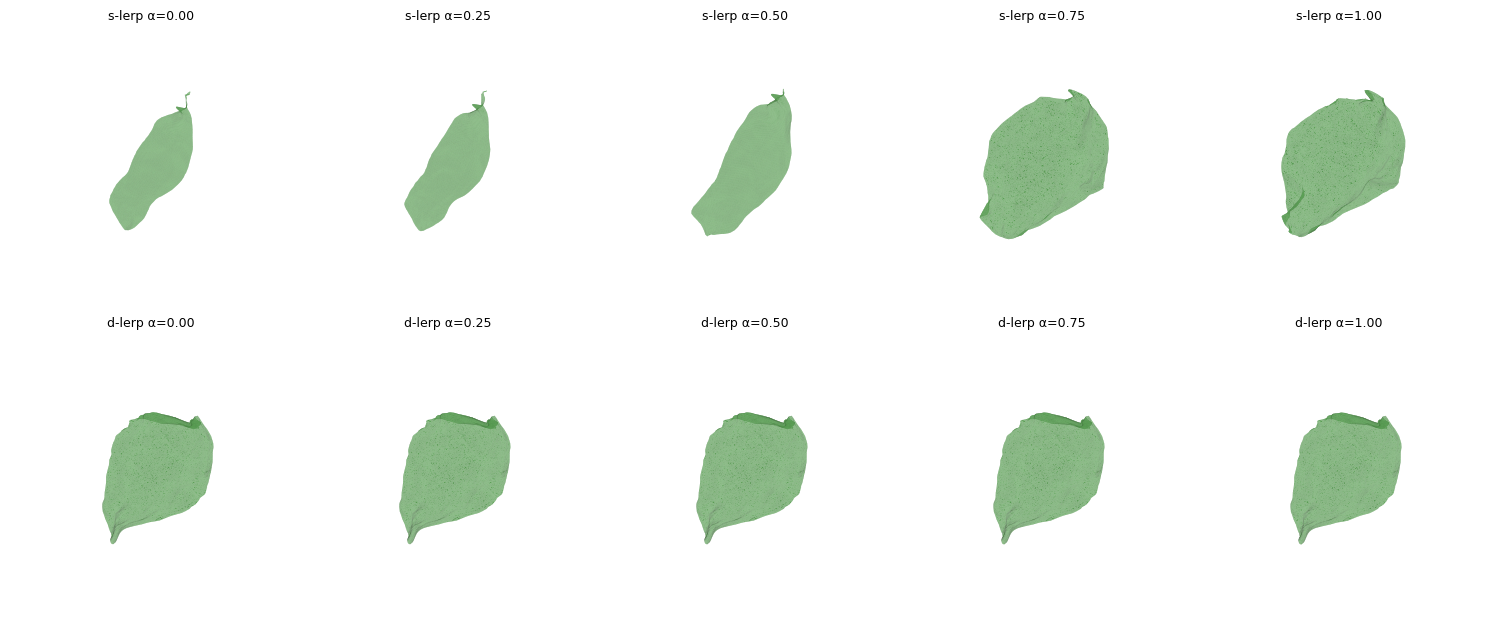

top row: shape interpolation | bottom row: deformation interpolation


In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt

n_steps = 5
sid1, sid2 = shape_ids[0], shape_ids[2]
rs_d = np.random.RandomState(1)
did1, did2 = [int(i) for i in rs_d.choice(len(deform_codes), 2, replace=False)]
print(f"shape interp: {sid1} -> {sid2} (deform {deform_id_demo} fixed) | "
      f"deform interp: {did1} -> {did2} (shape {shape_ids[1]} fixed)")

def gen_base(z_s):
    with torch.no_grad():
        mask = latent_to_mask(z_s.unsqueeze(0), shape_decoder, k=k, size=256)
        m = mask2mesh([mask]).to(device)
        bp = m.verts_packed().unsqueeze(0); bp = bp - bp.mean(1, keepdim=True)
        return bp, m.faces_packed().unsqueeze(0)

alphas = torch.linspace(0, 1, n_steps, device=device)
strip_s, strip_d = [], []
with torch.no_grad():
    for a in alphas:
        z_s = (1-a)*shape_codes[sid1] + a*shape_codes[sid2]     # shape interpolation
        bp, bf = gen_base(z_s)
        sw = sw_predictor(latent_code=z_s.unsqueeze(0), centers=bp)
        rts = trans_predictor(latent_code=deform_codes[deform_id_demo].unsqueeze(0), centers=bone)
        dp = generator.deform_lbs(bp, sw, rts)
        strip_s.append((dp[0].cpu().numpy(), bf[0].cpu().numpy()))   # verts AND faces per step
    bp, bf = gen_base(shape_codes[shape_ids[1]])
    bf_fixed = bf[0].cpu().numpy()
    sw = sw_predictor(latent_code=shape_codes[shape_ids[1]].unsqueeze(0), centers=bp)
    for a in alphas:
        z_d = (1-a)*deform_codes[did1] + a*deform_codes[did2]   # deformation interpolation
        rts = trans_predictor(latent_code=z_d.unsqueeze(0), centers=bone)
        dp = generator.deform_lbs(bp, sw, rts)
        strip_d.append((dp[0].cpu().numpy(), bf_fixed))

fig = plt.figure(figsize=(3.0*n_steps, 6.4))
for i in range(n_steps):
    ax = fig.add_subplot(2, n_steps, i+1, projection="3d")
    render_mesh(ax, strip_s[i][0], strip_s[i][1], elev=75, azim=-60, title=f"s-lerp α={alphas[i]:.2f}")
    ax = fig.add_subplot(2, n_steps, n_steps+i+1, projection="3d")
    render_mesh(ax, strip_d[i][0], strip_d[i][1], elev=75, azim=-60, title=f"d-lerp α={alphas[i]:.2f}")
plt.tight_layout(); plt.show()
print("top row: shape interpolation | bottom row: deformation interpolation")

### Step 5 — Fitting round-trip, part 1: target preparation and latent inversion (paper Sec. 5)
Creates **one target leaf** by deforming a chosen base shape with a *held-out* deformation code (never
used in the generation steps above), then runs the authors' reconstruction pipeline
(`fitting.py::Reconstructor`):
1. normalize the observed mesh to the canonical frame,
2. convert it to a 128³ occupancy voxel grid and **invert the latent codes** with the authors'
   3D-convolution encoders (`encoder.pth`; paper Eq. 14–15),
3. **rigidly register** the observation to the model's base shape with Coherent Point Drift (the
   authors' `rigid_cpd_cuda`, CuPy on GPU), including their z-flip disambiguation check.

Adaptation notes: `Reconstructor.single_leaf_predict` reads a module-global `args` for its output folder —
this notebook provides a minimal `SimpleNamespace` shim; the authors' z-flip chamfer check mixes GPU
and CPU point clouds, which PyTorch3D rejects, so a device-harmonizing wrapper is installed (same chamfer
algorithm, device placement only); and `neuralbs.py` forces the non-interactive `Agg` matplotlib backend,
so the inline display backend is restored after the import. No algorithmic change.
**フィッティング往復(前半)**: 未使用の deform コードでターゲット葉を生成し、著者のパイプライン(エンコーダによる潜在反転 + CPD 剛体レジストレーション)を実行します。

In [ ]:
import types, time, torch, numpy as np, os
import gc
gc.collect(); torch.cuda.empty_cache()      # defensive: release cached GPU blocks before fitting

# deterministic held-out target
rng_fit = np.random.RandomState(123)
fit_sid  = shape_ids[1]
fit_did  = int(rng_fit.choice([i for i in range(len(deform_codes)) if i != deform_id_demo]))
print(f"target: shape {fit_sid} deformed with held-out deform code {fit_did}")
with torch.no_grad():
    z_s_t = shape_codes[fit_sid].unsqueeze(0); z_d_t = deform_codes[fit_did].unsqueeze(0)
    mask_t = latent_to_mask(z_s_t, shape_decoder, k=k, size=256)
    mesh_t = mask2mesh([mask_t]).to(device)
    bp_t = mesh_t.verts_packed().unsqueeze(0); bp_t = bp_t - bp_t.mean(1, keepdim=True)
    sw_t = sw_predictor(latent_code=z_s_t, centers=bp_t)
    rts_t = trans_predictor(latent_code=z_d_t, centers=bone)
    target_pts = generator.deform_lbs(bp_t, sw_t, rts_t)[0]      # (N, 3) observed points

os.makedirs("/content/neuraleaf_results/fitting", exist_ok=True)
import fitting as fitting_module                                 # authors' fitting.py
# The authors' neuralbs.py calls matplotlib.use('Agg') (headless training habit), which disables
# figure display. Restore Colab's inline backend (environment adaptation only, no algorithm change).
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
fitting_module.args = types.SimpleNamespace(                     # shim for module-global args
    save_folder="/content/neuraleaf_results/fitting")

# Device-placement adaptation (documented): the authors' z-flip check calls chamfer_distance on
# point clouds living on different devices (registered points on GPU, model base mesh on CPU).
# PyTorch3D's kernel requires both tensors on the same device, so this wrapper moves them to a
# common device; the chamfer algorithm itself is unchanged.
from pytorch3d.loss import chamfer_distance as _chamfer_ref
def chamfer_distance(x, y, **kw):
    dev = x.device if x.is_cuda else y.device
    return _chamfer_ref(x.to(dev, non_blocking=True), y.to(dev, non_blocking=True), **kw)
fitting_module.chamfer_distance = chamfer_distance

# encoders for latent inversion (paper Eq. 14-15)
from scripts.models.encoder import ShapeEncoder
shape_latent_dim = shape_codes.shape[1]; deform_latent_dim = deform_codes.shape[1]
ck_enc = load_ckpt(find_ckpt("encoder.pth"))
shape_encoder  = ShapeEncoder(code_dim=shape_latent_dim,  res=128, output_dim=shape_latent_dim).to(device)
deform_encoder = ShapeEncoder(code_dim=deform_latent_dim, res=128, output_dim=deform_latent_dim).to(device)
shape_encoder.load_state_dict(ck_enc["shape_encoder"]); deform_encoder.load_state_dict(ck_enc["deform_encoder"])
shape_encoder.eval(); deform_encoder.eval()

reconstructor = fitting_module.Reconstructor(
    CFG_DEFORM, device, shape_decoder, sw_predictor, trans_predictor,
    shape_codes, deform_codes, bone, k,
    shape_encoder=shape_encoder, deform_encoder=deform_encoder,
    use_length_reg=False, use_arap=False)
print("Reconstructor ready (authors' fitting.py, unmodified apart from the module-level args shim "
      "and optional chamfer device adaptation above)")

target: shape 4415 deformed with held-out deform code 109


Reconstructor ready (authors' fitting.py, unmodified apart from the module-level args shim and optional chamfer device adaptation above)


### Step 5 (cont.) — Run the authors' single-leaf prediction entry point
`single_leaf_predict` takes a mesh file path; the observed points are therefore exported to a temporary
`.ply` (pytorch3d loader), then the authors' pipeline (normalization → encoder inversion → base-shape
generation → CPD rigid registration → z-flip check) is executed unmodified. The CPD registration runs on
GPU via CuPy and can take a few minutes for ~15k points.
**観測点群を一時 .ply に保存し、著者の `single_leaf_predict`(正規化→エンコーダ反転→CPD レジストレーション→反転判定)をそのまま実行します。**

In [ ]:
import time, torch, trimesh

mesh_path = "/content/neuraleaf_results/fitting/target_observed.ply"
trimesh.PointCloud(target_pts.detach().cpu().numpy()).export(mesh_path)   # points-only PLY
print("wrote", mesh_path, tuple(target_pts.shape))

t0 = time.time()
result = reconstructor.single_leaf_predict(mesh_path)                     # authors' pipeline, unmodified
print(f"single_leaf_predict done in {time.time()-t0:.0f} s | "
      f"registered points: {tuple(result['registered_points'].shape)}, "
      f"base mesh verts: {result['base_mesh'].verts_packed().shape[0]}")

wrote /content/neuraleaf_results/fitting/target_observed.ply (15000, 3)


Using original points (chamfer: 0.001791 <= 2.529145)
single_leaf_predict done in 105 s | registered points: (15000, 3), base mesh verts: 15000


### Step 5 (cont.) — Fitting round-trip, part 2: direct latent optimization (paper Sec. 5 / suppl. C.2)
Optimizes the shape and deformation latent codes (initialized by the encoder inversion) against the
registered observation with the authors' `neuraleaf_fitting`: per iteration the base shape is regenerated
from the current shape code, skinned with the current deformation code, and a bidirectional chamfer loss
plus Laplacian/edge regularizers is minimized (Adam; the authors' per-iteration schedule). The paper's
supplement prescribes 300 iterations — we run 300 and log the chamfer distance. Execution time and loss
curve are printed; the log is exported to `fitting_log.csv`.
**潜在コードを直接最適化(300 反復, 論文の設定)。Chamfer 距離の推移を記録し CSV 出力します。**

In [ ]:
import time, torch, numpy as np, matplotlib.pyplot as plt

EPOCHS = 300                                     # paper suppl. C.2: 300 iterations
save_path = "/content/neuraleaf_results/fitting/target_fitted.obj"

t0 = time.time()
loss_final, fitted_mesh = reconstructor.neuraleaf_fitting(
    result["base_mesh"], result["registered_points"],
    epoch=EPOCHS, save_mesh=True, save_path=save_path,
    shape_code_init=result["shape_code"], deform_code_init=result["deform_code"])
fit_time = time.time() - t0
print(f"fitting done: {fit_time:.0f} s for {EPOCHS} iterations | final chamfer {loss_final.item():.6f}")

/usr/local/lib/python3.13/dist-packages/pytorch3d/ops/laplacian_matrices.py:51: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  A = torch.sparse.FloatTensor(idx, ones, (V, V))


Epoch 0 loss: 0.017382, chamfer: 0.015136, scale: 1.00, rot: 0.1°, trans: [0.001,0.001,-0.001], smooth: 0.002118, edge: 0.000127, arap: 0.000


/usr/local/lib/python3.13/dist-packages/pytorch3d/io/obj_io.py:841: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  vert = [float_str % verts[i, j] for j in range(D)]


Epoch 100 loss: 0.004393, chamfer: 0.001784, scale: 1.06, rot: 4.6°, trans: [-0.000,0.060,0.042], smooth: 0.002459, edge: 0.000150, arap: 0.000


Epoch 200 loss: 0.002714, chamfer: 0.001700, scale: 1.08, rot: 5.4°, trans: [-0.023,0.072,0.036], smooth: 0.000813, edge: 0.000200, arap: 0.000


fitting done: 189 s for 300 iterations | final chamfer 0.001487


### Fitting round-trip — result visualization and export
Renders the registered observation points, the initial base shape, and the fitted NeuraLeaf mesh side by
side, then exports the fitting summary (iterations, wall time, final chamfer distance, target latent
indices) to `fitting_log.csv` inside the Colab runtime.
**フィッティング結果の可視化(観測点群/初期形状/適合結果)とサマリ CSV の出力を行います。**

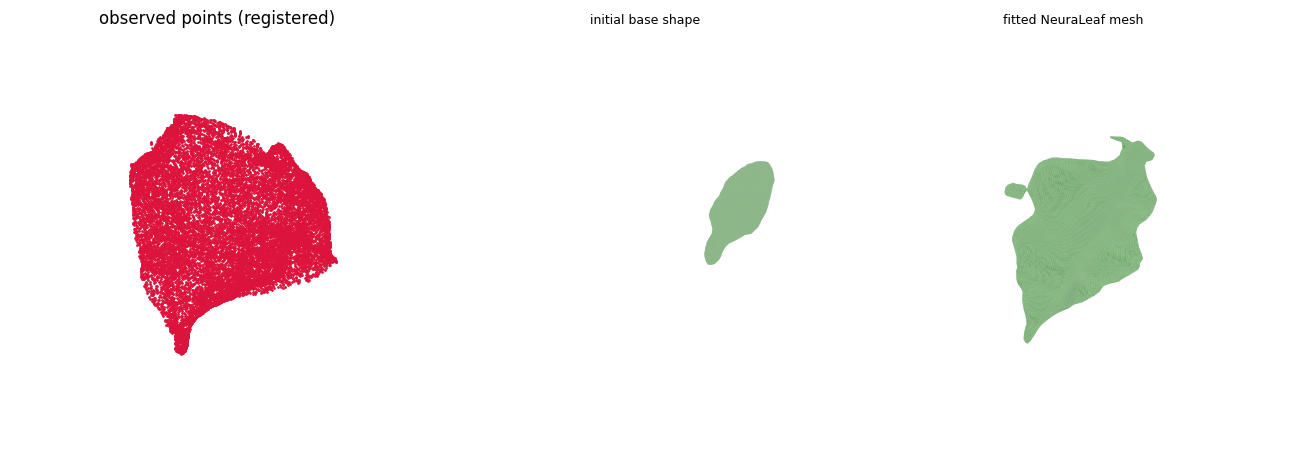

wrote /content/neuraleaf_results/fitting_log.csv
result files: ['deform_transfer.csv', 'fitting', 'fitting_log.csv']


In [ ]:
import matplotlib.pyplot as plt, numpy as np
v_fit, f_fit = mesh_arrays(fitted_mesh)
v_base, f_base = mesh_arrays(result["base_mesh"])
obs = result["registered_points"].detach().cpu().numpy()

fig = plt.figure(figsize=(13, 4.6))
ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.scatter(obs[:, 0], obs[:, 1], obs[:, 2], s=1, c="crimson", depthshade=False)
ax.set_title("observed points (registered)"); ax.set_axis_off(); ax.view_init(elev=75, azim=-60)
ax = fig.add_subplot(1, 3, 2, projection="3d"); render_mesh(ax, v_base, f_base, elev=75, azim=-60, title="initial base shape")
ax = fig.add_subplot(1, 3, 3, projection="3d"); render_mesh(ax, v_fit, f_fit, elev=75, azim=-60, title="fitted NeuraLeaf mesh")
plt.tight_layout(); plt.show()

with open("/content/neuraleaf_results/fitting_log.csv", "w") as fh:
    fh.write("metric,value\n")
    fh.write(f"fitting_iterations,{EPOCHS}\n")
    fh.write(f"fitting_time_s,{fit_time:.1f}\n")
    fh.write(f"final_chamfer,{loss_final.item():.8f}\n")
    fh.write(f"target_shape_idx,{fit_sid}\n")
    fh.write(f"target_deform_idx,{fit_did}\n")
print("wrote /content/neuraleaf_results/fitting_log.csv")
import os
print("result files:", sorted(os.listdir("/content/neuraleaf_results")))

## Interpretation and limitations / 結果の解釈と限界

**What the outputs above show (partial demonstration):**
- Step 1–2: the pretrained shape decoder produces closed leaf silhouettes from latent codes, and the
  skeleton-free skinning model deforms them (this is the paper's core representation, Sec. 3.1/3.3).
- Step 3: one fixed deformation latent deforms different base species consistently — the paper's
  disentanglement claim (Fig. 7). The CSV records per-mesh deformation magnitudes.
- Step 4: interpolation strips show smooth latent spaces (Fig. S2/S3 behavior).
- Step 5: the authors' full fitting pipeline (encoder inversion + CPD registration + direct latent
  optimization) recovers a deformed leaf from points — a **round-trip on model-generated input**, which
  exercises the pipeline but is weaker evidence than fitting a real scan (the paper's Table-1 setting).

**Differences from the paper / adaptations (all documented above):**
- Conference-version code + its pretrained weights (operator-directed); core files byte-identical to the
  journal repo. Journal-only appearance/PBR parts are not demonstrated (no public weights).
- `latent_to_mask` uses hardsigmoid (code) where the paper Eq. 2 writes a sigmoid with learnable k —
  the authors' code is authoritative here.
- A device-harmonizing wrapper around `chamfer_distance` is installed because the released z-flip check
  feeds it GPU and CPU point clouds simultaneously (device placement only; same algorithm). The authors'
  `neuralbs.py` also forces the `Agg` matplotlib backend; Colab's inline backend is restored so figures
  display (environment adaptation).
- The paper's fitting supplement prescribes latent regularization L_reg; the released
  `neuraleaf_fitting` minimizes chamfer + Laplacian + edge losses — we run the authors' released code.

**Not verified here:** dataset-level reconstruction accuracies (paper Tables 1–3), training behaviour,
texture/appearance generation, and fits to real DeformLeaf scans.

**制限事項(日本語)**: 本ノートブックは最小例による部分的再現です。会議版実装・重みを使用し(コア部分はジャーナル版と同一)、テクスチャ/外観生成・学習・データセット規模の定量評価は対象外です。フィッティングはモデル生成葉に対する往復実験であり、実スキャンへの適合(論文 Table 1 の設定)は検証していません。

## References
- Yang, Shinoda, Santo, Matsushita, Okura. *NeuraLeaf: Disentangled Neural Parametric Modeling of Leaf Shape, Deformation, and Appearance.* IJCV 134(10), 2026. DOI 10.1007/s11263-026-03024-6.
- Yang, Mao, Santo, Matsushita, Okura. *NeuraLeaf: Neural Parametric Leaf Models with Shape and Deformation Disentanglement.* ICCV 2025 (arXiv:2507.12714v2) — version used for method text here.
- Code: github.com/Yrainy0615/NeuraLeaf @782cafe (executed), github.com/Yrainy0615/NeuraLeaf-APP @1d5b366 (journal repo, core byte-identical).